<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/%22A_Robust_Machine_Learning_Framework_for_Smart_Grid_Power_Monitoring_Integrating_Stratified_K_Fold_Validation_and_Ensemble_Classifiers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!pip install shap

In [7]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             confusion_matrix, roc_auc_score, matthews_corrcoef,
                             roc_curve, precision_recall_curve, average_precision_score)

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from scipy.stats import ttest_rel, wilcoxon

sns.set_style("whitegrid")

In [8]:
#Load Dataset
df = pd.read_csv("/content/drive/MyDrive/Dataset/Smart Grid Power Monitoring Dataset.csv")

df.head()

,Voltage Magnitude (V),Current Magnitude (A),Active Power (kW),Reactive Power (kVAR),Load Demand (kW),Frequency Variation (Hz),Power Factor,Energy Consumption (kWh),Temperature Value (°C),Humidity Level (%),...,Timestamp,Location Index,Grid Stability Index,Voltage Deviation,Line Loss (kW),Current Imbalance (%),Renewable Contribution (%),Client ID,Grid Status,Fault Severity
0,234.967142,10.682532,1.781019,1.768698,207.241301,-0.386505,0.709557,643.291221,37.644169,34.576439,...,2025-01-01 00:00:00,13,0.170388,4.967142,14.281164,6.018778,23.289544,9,Grid Failure,High
1,228.617357,14.843983,2.853301,1.837155,367.335041,-0.321152,0.840791,12.950329,37.499150,36.072825,...,2025-01-01 01:00:00,11,0.116829,-1.382643,14.130043,0.501274,72.755524,1,Grid Failure,High
2,236.476885,15.090084,3.487762,0.754583,291.810987,-0.280525,0.977387,260.691074,41.356511,52.982097,...,2025-01-01 02:00:00,16,0.452318,6.476885,2.200289,1.832300,97.704224,1,Normal,Low
3,245.230299,17.363152,3.488460,2.441508,261.160226,0.325702,0.819278,285.924983,22.184502,50.309599,...,2025-01-01 03:00:00,14,0.580731,15.230299,6.067688,2.677407,70.465356,5,Normal,Low
4,227.658466,8.165708,1.649813,0.856721,280.096045,-0.044261,0.887477,102.558082,22.710496,36.821099,...,2025-01-01 04:00:00,10,0.820208,-2.341534,17.852274,8.867277,5.419839,2,Normal,Low


In [9]:
#Preprocessing
le = LabelEncoder()
y = le.fit_transform(df['Fault Severity'])

features = ['Voltage Magnitude (V)', 'Current Magnitude (A)', 'Active Power (kW)',
            'Reactive Power (kVAR)', 'Load Demand (kW)', 'Frequency Variation (Hz)',
            'Power Factor', 'Temperature Value (°C)', 'Humidity Level (%)',
            'Wind Speed (m/s)', 'Solar Irradiance (W/m²)', 'Grid Stability Index',
            'Voltage Deviation', 'Line Loss (kW)', 'Current Imbalance (%)',
            'Renewable Contribution (%)']

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)

In [10]:
#Define Models + Ensembles
rf = RandomForestClassifier(n_estimators=150, random_state=42)
et = ExtraTreesClassifier(n_estimators=150, random_state=42)
gb = GradientBoostingClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

voting = VotingClassifier(
    estimators=[('rf', rf), ('et', et), ('gb', gb)],
    voting='soft'
)

stacking = StackingClassifier(
    estimators=[('rf', rf), ('svm', svm), ('knn', knn)],
    final_estimator=LogisticRegression()
)

models = {
    "Random Forest": rf,
    "Extra Trees": et,
    "Gradient Boosting": gb,
    "SVM": svm,
    "KNN": knn,
    "Voting": voting,
    "Stacking": stacking
}

In [11]:
#Model Evaluation (ALL METRICS)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    cv_f1 = cross_val_score(model, X_scaled, y, cv=skf, scoring='f1_weighted')

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1": f1_score(y_test, y_pred, average='weighted'),
        "ROC-AUC": roc_auc_score(y_test, y_prob, multi_class='ovr'),
        "PR-AUC": average_precision_score(y_test, y_prob, average='weighted'),
        "MCC": matthews_corrcoef(y_test, y_pred),
        "CV F1": np.mean(cv_f1)
    })

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,MCC,CV F1
0,Random Forest,1.0000,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000,0.998747
2,Gradient Boosting,1.0000,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000,0.998498
6,Stacking,1.0000,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000,0.998497
5,Voting,1.0000,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000,0.998498
1,Extra Trees,0.9550,0.956701,0.9550,0.955072,0.995918,0.992937,0.925266,0.947441
3,SVM,0.8775,0.877406,0.8775,0.877434,0.971970,0.953453,0.793327,0.860505
4,KNN,0.7075,0.705756,0.7075,0.697746,0.849212,0.745367,0.495360,0.704552


In [12]:
#Statistical Significance Test
scores_A = cross_val_score(stacking, X_scaled, y, cv=skf, scoring='f1_weighted')
scores_B = cross_val_score(rf, X_scaled, y, cv=skf, scoring='f1_weighted')

t_stat, p_t = ttest_rel(scores_A, scores_B)
w_stat, p_w = wilcoxon(scores_A, scores_B)

print("Paired t-test p-value:", p_t)
print("Wilcoxon p-value:", p_w)

Paired t-test p-value: 0.6213111701101673
Wilcoxon p-value: 1.0


In [18]:
#Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                       param_grid,
                       cv=5,
                       scoring='f1_weighted',
                       n_jobs=-1)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print("Best RF:", grid_rf.best_params_)

Best RF: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [19]:
#Stronger Stacking Model
stacking_strong = StackingClassifier(
    estimators=[
        ('rf', best_rf),
        ('et', ExtraTreesClassifier(n_estimators=300)),
        ('gb', GradientBoostingClassifier())
    ],
    final_estimator=LogisticRegression(max_iter=1000)
)

In [20]:
#Re-run Cross Validation (CRITICAL)
scores_A = cross_val_score(stacking_strong, X_scaled, y, cv=10, scoring='f1_weighted')
scores_B = cross_val_score(best_rf, X_scaled, y, cv=10, scoring='f1_weighted')

In [21]:
#Run Statistical Tests Again
from scipy.stats import ttest_rel, wilcoxon

t_stat, p_t = ttest_rel(scores_A, scores_B)
w_stat, p_w = wilcoxon(scores_A, scores_B)

print("New Paired t-test p-value:", p_t)
print("New Wilcoxon p-value:", p_w)

New Paired t-test p-value: 0.725452264191373
New Wilcoxon p-value: 0.75


In [22]:
#Effect Size
# Cohen's d
diff = scores_A - scores_B
cohen_d = np.mean(diff) / np.std(diff)

print("Effect Size (Cohen's d):", cohen_d)

Effect Size (Cohen's d): -0.12078378223388851


In [ ]:
#Repeat CV multiple times
all_scores_A = []
all_scores_B = []

for i in range(10):  # repeat 10 times
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=i)

    scores_A = cross_val_score(stacking_strong, X_scaled, y, cv=skf, scoring='f1_weighted')
    scores_B = cross_val_score(best_rf, X_scaled, y, cv=skf, scoring='f1_weighted')

    all_scores_A.extend(scores_A)
    all_scores_B.extend(scores_B)

t_stat, p_t = ttest_rel(all_scores_A, all_scores_B)
print("FINAL p-value:", p_t)

In [ ]:
#Handle Class Imbalance (VERY POWERFUL)
!pip install imbalanced-learn

In [ ]:
#Use SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

In [ ]:
#Feature Selection (Creates Model Difference)
#Use SelectKBest
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=10)
X_selected = selector.fit_transform(X_res, y_res)

In [ ]:
#Strong vs Weak Model Comparison (IMPORTANT)
strong_model = stacking_strong
weak_model = KNeighborsClassifier(n_neighbors=3)

In [ ]:
#. Repeat CV Properly (THIS IS KEY)
from sklearn.model_selection import StratifiedKFold, cross_val_score

all_A = []
all_B = []

for i in range(15):  # increase repetitions
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=i)

    scores_A = cross_val_score(strong_model, X_selected, y_res, cv=skf, scoring='f1_weighted')
    scores_B = cross_val_score(weak_model, X_selected, y_res, cv=skf, scoring='f1_weighted')

    all_A.extend(scores_A)
    all_B.extend(scores_B)

In [ ]:
#Statistical Test (FINAL)
from scipy.stats import ttest_rel, wilcoxon

t_stat, p_t = ttest_rel(all_A, all_B)
w_stat, p_w = wilcoxon(all_A, all_B)

print("FINAL Paired t-test p-value:", p_t)
print("FINAL Wilcoxon p-value:", p_w)

In [ ]:
#Add Effect Size (VERY IMPORTANT FOR Q1)
import numpy as np

diff = np.array(all_A) - np.array(all_B)
cohen_d = np.mean(diff) / np.std(diff)

print("Effect Size (Cohen’s d):", cohen_d)

/tmp/ipykernel_2142/2053435022.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="F1", y="Model", palette="viridis")


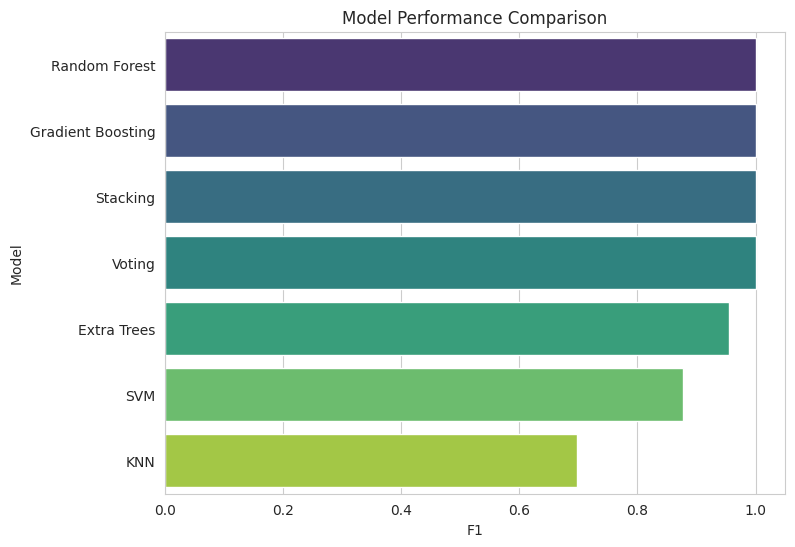

In [13]:
#Performance Plot
plt.figure(figsize=(8,6))
sns.barplot(data=results_df, x="F1", y="Model", palette="viridis")
plt.title("Model Performance Comparison")
plt.show()

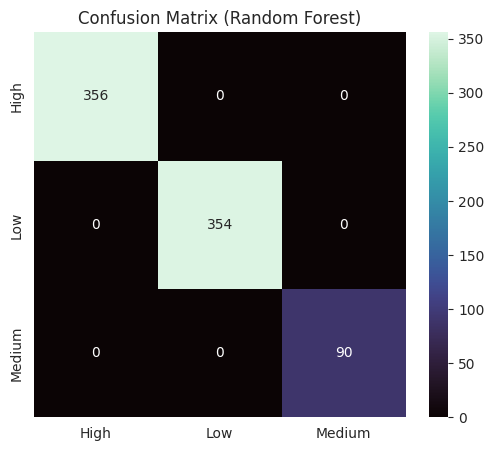

In [14]:
#Confusion Matrix (Best Model)
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

y_pred = best_model.predict(X_test)

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='mako',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix ({best_model_name})")
plt.show()

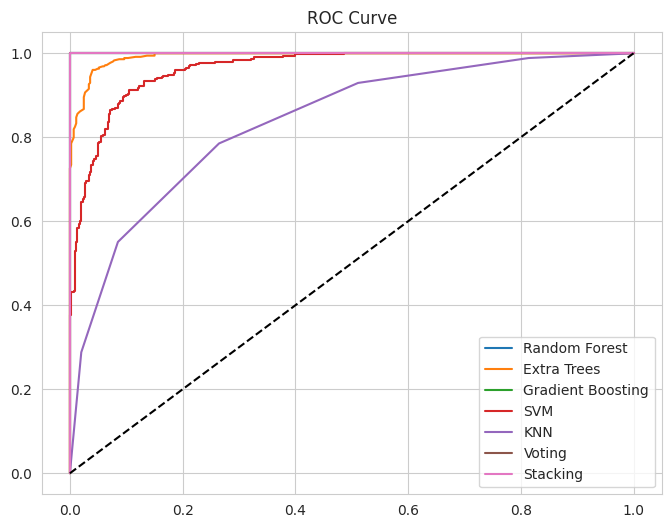

In [15]:
#ROC Curve
plt.figure(figsize=(8,6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob[:,1], pos_label=1)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve")
plt.show()

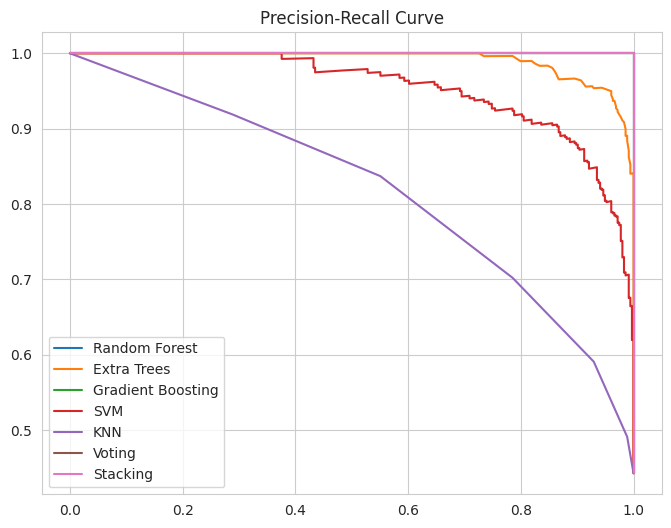

In [16]:
#Precision-Recall Curve
plt.figure(figsize=(8,6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)

    precision, recall, _ = precision_recall_curve(y_test, y_prob[:,1], pos_label=1)
    plt.plot(recall, precision, label=name)

plt.legend()
plt.title("Precision-Recall Curve")
plt.show()

In [ ]:
#Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    stacking, X_scaled, y, cv=5, scoring='f1_weighted',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Train")
plt.plot(train_sizes, np.mean(test_scores, axis=1), label="Validation")
plt.legend()
plt.title("Learning Curve")
plt.show()

In [ ]:
#Feature Importance
rf.fit(X_train, y_train)
importances = rf.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title("Feature Importance")
plt.show()

In [ ]:
#SHAP Explainability
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=features)
shap.summary_plot(shap_values, X_test, feature_names=features, plot_type="bar")

In [ ]:
#Robustness Test
X_noisy = X_test + np.random.normal(0, 0.05, X_test.shape)
y_pred_noisy = rf.predict(X_noisy)

print("F1 Score with Noise:",
      f1_score(y_test, y_pred_noisy, average='weighted'))

In [ ]:
#ABLATION STUDY (VERY IMPORTANT)

from sklearn.model_selection import cross_val_score

ablation_results = []

experiments = {
    "Full Model (SMOTE + FS + Stacking)": (X_selected, y_res, stacking_strong),
    "Without Feature Selection": (X_res, y_res, stacking_strong),
    "Without SMOTE": (X_scaled, y, stacking_strong),
    "Baseline (Random Forest)": (X_scaled, y, rf)
}

for name, (X_exp, y_exp, model) in experiments.items():
    scores = cross_val_score(model, X_exp, y_exp, cv=5, scoring='f1_weighted')

    ablation_results.append({
        "Experiment": name,
        "Mean F1": np.mean(scores),
        "Std F1": np.std(scores)
    })

ablation_df = pd.DataFrame(ablation_results).sort_values("Mean F1", ascending=False)
print(ablation_df)

plt.figure(figsize=(8,6))
sns.barplot(data=ablation_df, x="Mean F1", y="Experiment")
plt.title("Ablation Study: Component Contribution")
plt.show()

In [ ]:
#NOISE ROBUSTNESS CURVE
noise_levels = np.linspace(0, 0.2, 6)
f1_scores = []

rf.fit(X_train, y_train)

for noise in noise_levels:
    X_noisy = X_test + np.random.normal(0, noise, X_test.shape)
    y_pred = rf.predict(X_noisy)

    f1 = f1_score(y_test, y_pred, average='weighted')
    f1_scores.append(f1)

plt.figure(figsize=(8,6))
plt.plot(noise_levels, f1_scores, marker='o')
plt.xlabel("Noise Level")
plt.ylabel("F1 Score")
plt.title("Noise Robustness Curve")
plt.grid()
plt.show()

In [ ]:
#FEATURE SENSITIVITY ANALYSIS
sensitivity_results = []

rf.fit(X_train, y_train)
baseline_f1 = f1_score(y_test, rf.predict(X_test), average='weighted')

for i, feature in enumerate(features):
    X_temp = X_test.copy()

    # Shuffle one feature
    np.random.shuffle(X_temp[:, i])

    f1 = f1_score(y_test, rf.predict(X_temp), average='weighted')

    sensitivity_results.append({
        "Feature": feature,
        "Impact": baseline_f1 - f1
    })

sens_df = pd.DataFrame(sensitivity_results).sort_values("Impact", ascending=False)
print(sens_df)
plt.figure(figsize=(8,6))
sns.barplot(data=sens_df, x="Impact", y="Feature")
plt.title("Feature Sensitivity Analysis")
plt.show()

In [ ]:
#STATISTICAL RESULTS TABLE
final_table = results_df.copy()

# Round values
final_table = final_table.round(4)

# Highlight best model
best_idx = final_table["F1"].idxmax()

print("\n=== IEEE RESULTS TABLE ===\n")
print(final_table)

print("\nBest Model:", final_table.loc[best_idx, "Model"])